# COVID-19 Forecasting

## 1. Imports

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Upload / load the dataset

In [ ]:
DATA_PATH = "CONVENIENT_us_confirmed_cases.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            DATA_PATH = list(uploaded.keys())[0]
    except Exception:
        pass

print("Using dataset:", DATA_PATH)

Saving CONVENIENT_us_confirmed_cases.csv to CONVENIENT_us_confirmed_cases.csv
Using dataset: CONVENIENT_us_confirmed_cases.csv


## 3. Load and clean the dataset



In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.iloc[1:].copy()

print("Data loaded")
display(df.head())

print("Available columns in df:", df.columns.tolist()[:10], "...")
target_country = "US"

dates = df["Province_State"]
case_columns = df.iloc[:, 1:]
case_data_numeric = case_columns.apply(pd.to_numeric, errors="coerce").fillna(0)
total_new_cases = case_data_numeric.sum(axis=1)

US_data = pd.DataFrame({
    "Date": dates,
    "New_Cases": total_new_cases
}).copy()

US_data["Date"] = pd.to_datetime(US_data["Date"], format="%m/%d/%y")
US_data["New_Cases"] = pd.to_numeric(US_data["New_Cases"], errors="coerce").fillna(0)
US_data.loc[US_data["New_Cases"] < 0, "New_Cases"] = 0

print(f"Dataset for {target_country} prepared and cleaned.")
display(US_data.head())
display(US_data.tail())
print("Rows:", len(US_data))

Data loaded


,Province_State,Alabama,Alabama.1,Alabama.2,Alabama.3,Alabama.4,Alabama.5,Alabama.6,Alabama.7,Alabama.8,...,Wyoming.15,Wyoming.16,Wyoming.17,Wyoming.18,Wyoming.19,Wyoming.20,Wyoming.21,Wyoming.22,Wyoming.23,Wyoming.24
1,1/23/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1/24/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/25/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/26/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1/27/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Available columns in df: ['Province_State', 'Alabama', 'Alabama.1', 'Alabama.2', 'Alabama.3', 'Alabama.4', 'Alabama.5', 'Alabama.6', 'Alabama.7', 'Alabama.8'] ...
Dataset for US prepared and cleaned.


,Date,New_Cases
1,2020-01-23,0.0
2,2020-01-24,1.0
3,2020-01-25,0.0
4,2020-01-26,3.0
5,2020-01-27,0.0


,Date,New_Cases
1138,2023-03-05,0.0
1139,2023-03-06,8564.0
1140,2023-03-07,35371.0
1141,2023-03-08,64861.0
1142,2023-03-09,46931.0


Rows: 1142


## 4. Basic checks and visualisation

Missing values in raw df:


,0
Province_State,0
Alabama,0
Alabama.1,0
Alabama.2,0
Alabama.3,0


Duplicate rows in raw df: 0


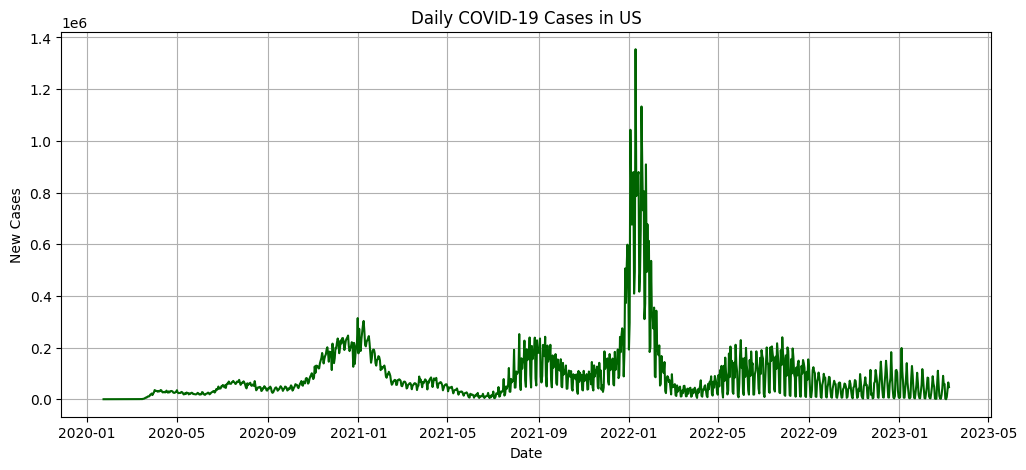

In [ ]:
print("Missing values in raw df:")
display(df.isnull().sum().head())

print("Duplicate rows in raw df:", df.duplicated().sum())

plt.figure(figsize=(12, 5))
plt.plot(US_data["Date"], US_data["New_Cases"], color="darkgreen")
plt.title(f"Daily COVID-19 Cases in {target_country}")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.grid(True)
plt.show()

## 5. Transform and scale the series



In [ ]:
data = US_data.set_index("Date")[["New_Cases"]].copy()

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.values.reshape(-1, 1))

print("Scaled data shape:", data_scaled.shape)
print("Scaled min/max:", data_scaled.min(), data_scaled.max())

Scaled data shape: (1142, 1)
Scaled min/max: 0.0 0.9999999999999999


## 6. Create time-series sequences

In [ ]:
def create_sequences(data_array, look_back):
    X, y = [], []
    for i in range(len(data_array) - look_back):
        X.append(data_array[i:(i + look_back), 0])
        y.append(data_array[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 30
X, y = create_sequences(data_scaled, look_back)

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (labels): {y.shape}")

Shape of X (features): (1112, 30)
Shape of y (labels): (1112,)


## 7. Train-test split (time-series order preserved)

In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train_reshaped:", X_train_reshaped.shape)
print("X_test_reshaped:", X_test_reshaped.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_reshaped: (889, 30, 1)
X_test_reshaped: (223, 30, 1)
y_train: (889,)
y_test: (223,)


## 8. Building models
- **LSTM**
- **GRU**
- **Ensemble**



In [ ]:
tf.keras.backend.clear_session()

model_lstm = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mean_squared_error")

model_gru = Sequential([
    Input(shape=(look_back, 1)),
    GRU(50, return_sequences=True),
    Dropout(0.2),
    GRU(50),
    Dense(1)
])
model_gru.compile(optimizer="adam", loss="mean_squared_error")

model_lstm.summary()
model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train models

In [ ]:
history_lstm = model_lstm.fit(
    X_train_reshaped,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test),
    verbose=1
)

history_gru = model_gru.fit(
    X_train_reshaped,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test),
    verbose=1
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0053 - val_loss: 0.0014
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.002

## 10. Evaluate on the test set

In [ ]:
pred_lstm_scaled = model_lstm.predict(X_test_reshaped, verbose=0)
pred_gru_scaled = model_gru.predict(X_test_reshaped, verbose=0)
ensemble_pred_scaled = (pred_lstm_scaled + pred_gru_scaled) / 2

pred_lstm = scaler.inverse_transform(pred_lstm_scaled)
pred_gru = scaler.inverse_transform(pred_gru_scaled)
ensemble_pred = scaler.inverse_transform(ensemble_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))
mae_lstm = mean_absolute_error(y_test_actual, pred_lstm)

rmse_gru = np.sqrt(mean_squared_error(y_test_actual, pred_gru))
mae_gru = mean_absolute_error(y_test_actual, pred_gru)

rmse_ensemble = np.sqrt(mean_squared_error(y_test_actual, ensemble_pred))
mae_ensemble = mean_absolute_error(y_test_actual, ensemble_pred)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE :", mae_lstm)
print("GRU RMSE :", rmse_gru)
print("GRU MAE  :", mae_gru)
print("Ensemble RMSE:", rmse_ensemble)
print("Ensemble MAE :", mae_ensemble)

LSTM RMSE: 48839.32624804589
LSTM MAE : 40170.45228419283
GRU RMSE : 49690.8305197177
GRU MAE  : 40905.40850966928
Ensemble RMSE: 48425.21384908471
Ensemble MAE : 40171.8193403167


## 11. Visualise model performance

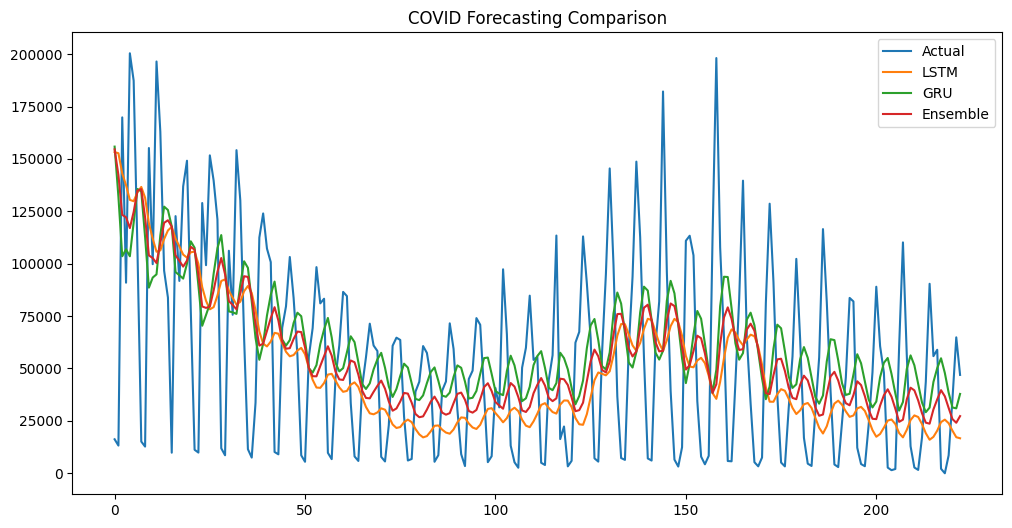

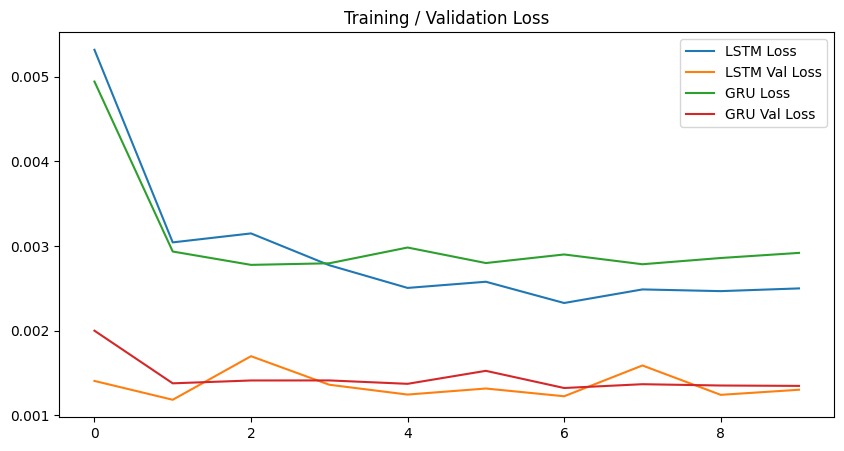

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual")
plt.plot(pred_lstm, label="LSTM")
plt.plot(pred_gru, label="GRU")
plt.plot(ensemble_pred, label="Ensemble")
plt.legend()
plt.title("COVID Forecasting Comparison")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history["loss"], label="LSTM Loss")
plt.plot(history_lstm.history["val_loss"], label="LSTM Val Loss")
plt.plot(history_gru.history["loss"], label="GRU Loss")
plt.plot(history_gru.history["val_loss"], label="GRU Val Loss")
plt.legend()
plt.title("Training / Validation Loss")
plt.show()

## 12. Simple uncertainty band from repeated LSTM inference

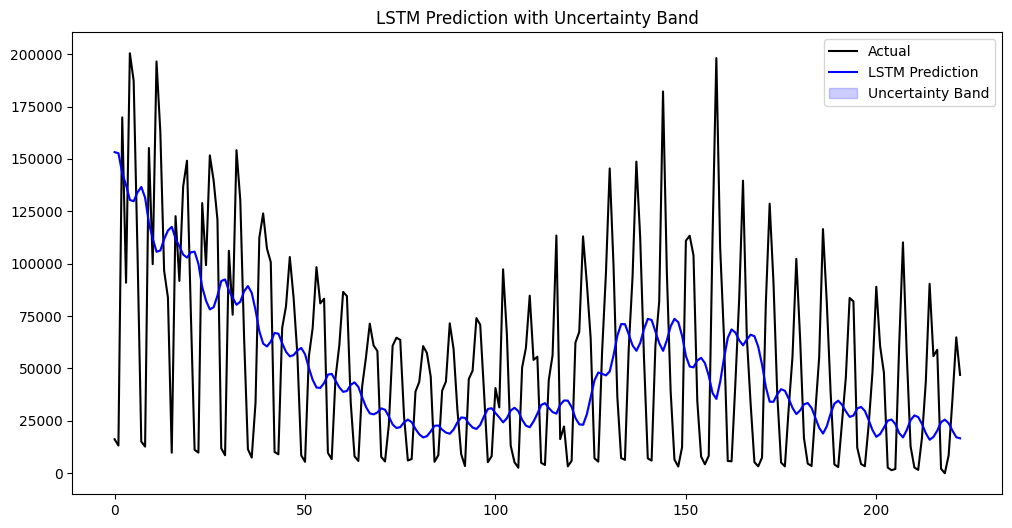

In [ ]:
preds = []
for _ in range(5):
    temp_pred = model_lstm.predict(X_test_reshaped, verbose=0)
    preds.append(temp_pred)

preds = np.array(preds)

upper = np.max(preds, axis=0)
lower = np.min(preds, axis=0)

upper = scaler.inverse_transform(upper)
lower = scaler.inverse_transform(lower)

plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", color="black")
plt.plot(pred_lstm, label="LSTM Prediction", color="blue")
plt.fill_between(
    np.arange(len(pred_lstm.flatten())),
    lower.flatten(),
    upper.flatten(),
    color="blue",
    alpha=0.2,
    label="Uncertainty Band"
)
plt.legend()
plt.title("LSTM Prediction with Uncertainty Band")
plt.show()

## 13. Future forecasting loop

In [ ]:
def forecast_future(model, scaler, original_values, look_back=30, forecast_days=14):
    scaled_values = scaler.transform(original_values.reshape(-1, 1))
    current_sequence = scaled_values[-look_back:].copy()

    future_scaled = []

    for _ in range(forecast_days):
        x_input = current_sequence.reshape(1, look_back, 1)
        pred = model.predict(x_input, verbose=0)[0][0]
        future_scaled.append(pred)

        pred_arr = np.array([[pred]])
        current_sequence = np.vstack([current_sequence[1:], pred_arr])

    future = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()
    future = np.maximum(future, 0)
    return future

forecast_days = 14
future_lstm = forecast_future(
    model=model_lstm,
    scaler=scaler,
    original_values=data["New_Cases"].values.astype(float),
    look_back=look_back,
    forecast_days=forecast_days
)

last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=forecast_days + 1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_New_Cases": np.round(future_lstm, 2)
})

display(future_df)

,Date,Predicted_New_Cases
0,2023-03-10,17393.140625
1,2023-03-11,16943.410156
2,2023-03-12,15477.940430
3,2023-03-13,13348.070312
4,2023-03-14,10467.570312
5,2023-03-15,6904.660156
6,2023-03-16,2651.360107
7,2023-03-17,0.000000
8,2023-03-18,0.000000
9,2023-03-19,0.000000


## 14. Plot future forecast

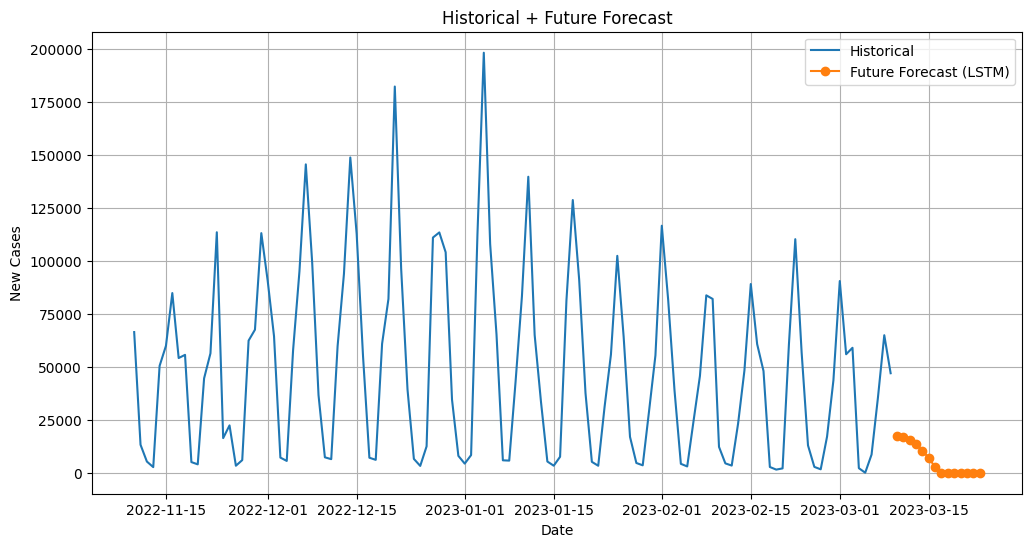

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data.index[-120:], data["New_Cases"].values[-120:], label="Historical")
plt.plot(future_df["Date"], future_df["Predicted_New_Cases"], label="Future Forecast (LSTM)", marker="o")
plt.legend()
plt.title("Historical + Future Forecast")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.grid(True)
plt.show()

## 15. Save files for the Streamlit app

In [ ]:
model_lstm.save_weights("lstm_model.weights.h5")
joblib.dump(scaler, "scaler.pkl")

print("Saved files:")
print("- lstm_model.weights.h5")
print("- scaler.pkl")
print("\nCurrent directory contents:")
print(os.listdir("."))

Saved files:
- lstm_model.weights.h5
- scaler.pkl

Current directory contents:
['.config', 'lstm_model.weights.h5', 'CONVENIENT_us_confirmed_cases.csv', 'scaler.pkl', 'sample_data']
